In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.lattice_surgery.circuit import surgery_circuit

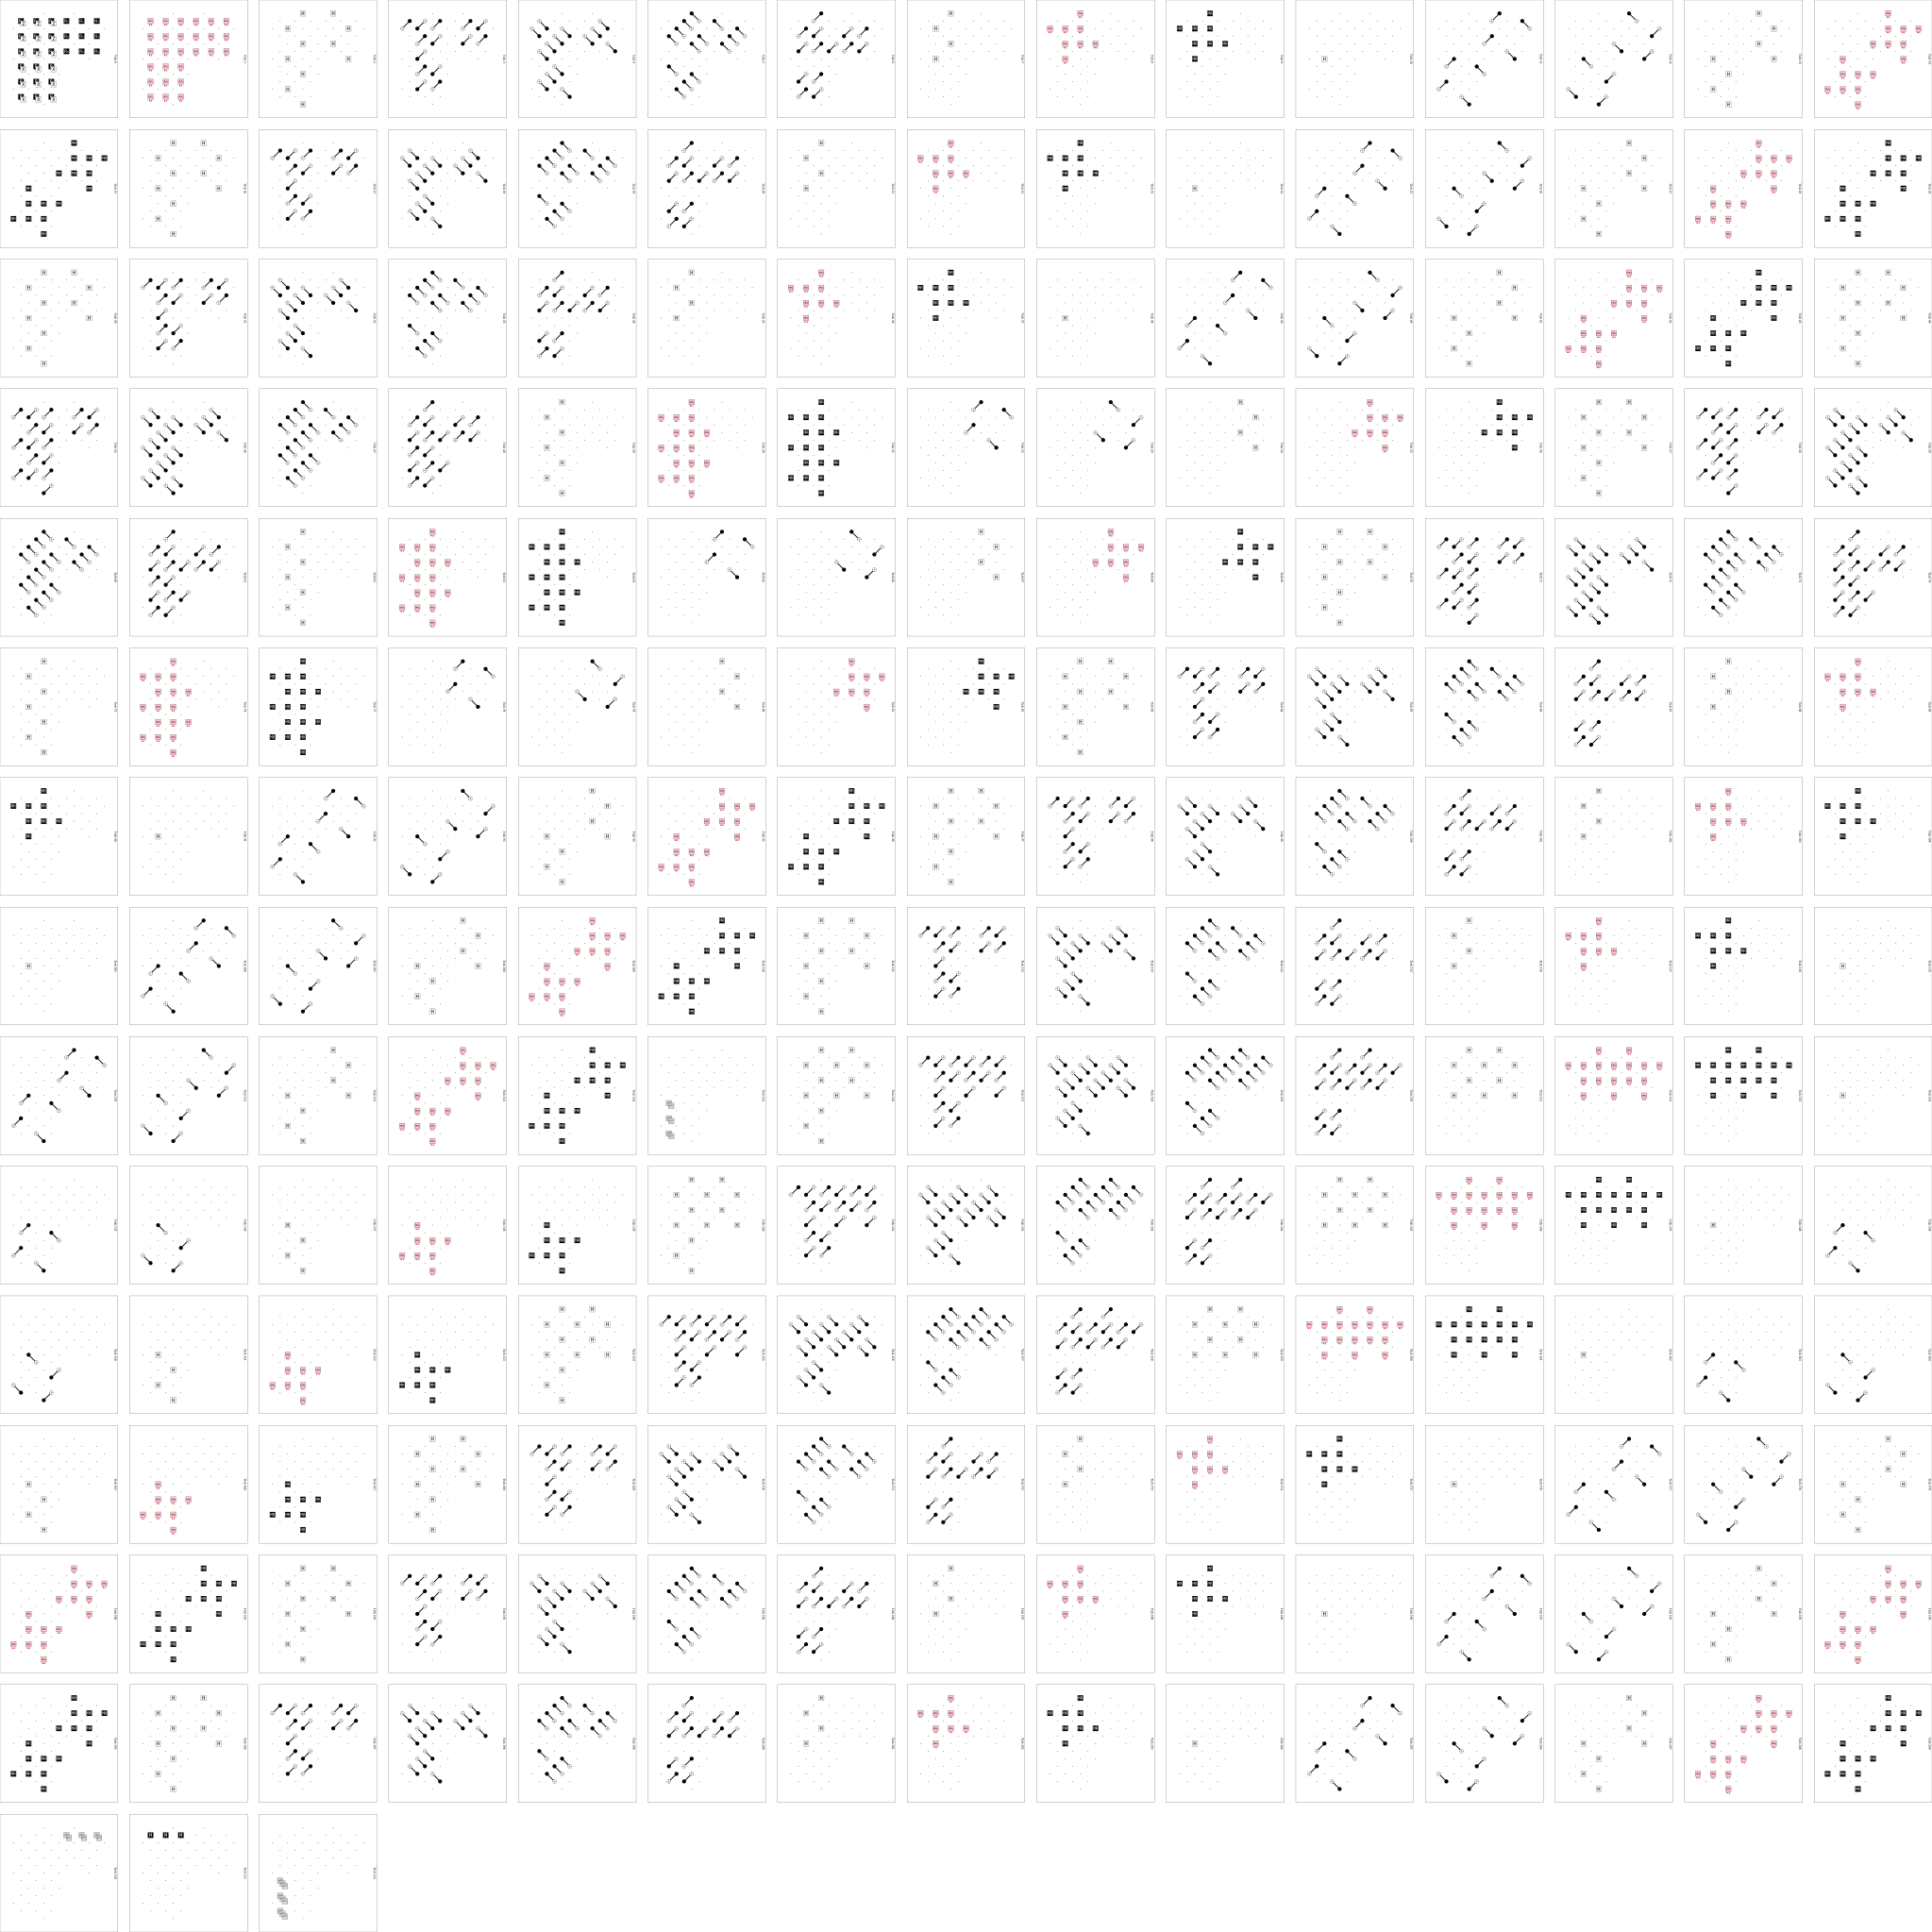

In [19]:
test_circuit = surgery_circuit(3, target_state_init="X-", control_state_init="Z1", noise_depol_data_init = 0.1,noise_measure_flip = 0.1).diagram("timeslice-svg")
test_circuit

In [13]:
task_noisy = [sinter.Task(
    circuit = surgery_circuit(
        distance = d,
        control_state_init = "X+",
        target_state_init = "X+",
        noise_depol_data_init = noise,
        noise_measure_flip = noise
    ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.0001, 0.00025, 0.0005, 0.001, 0.010, 0.015, 0.1, 0.125, 0.2, 0.3, 0.35, 0.4, 0.45]
    for d in [3,5,7]
    ]

stats_noisy : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=1000,
    print_progress=True
)

Starting 8 workers...
39 tasks left:
  workers    decoder eta shots_left errors_left json_metadata       
        1 pymatching   ?    1000000        1000 p=0.0001,distance=3 
        1 pymatching   ?    1000000        1000 p=0.0001,distance=5 
        1 pymatching   ?    1000000        1000 p=0.0001,distance=7 
        1 pymatching   ?    1000000        1000 p=0.00025,distance=3
        1 pymatching   ?    1000000        1000 p=0.00025,distance=5
        1 pymatching   ?    1000000        1000 p=0.00025,distance=7
        1 pymatching   ?     999983        1000 p=0.0005,distance=3 
        1 pymatching   ?    1000000        1000 p=0.0005,distance=5 
        0 pymatching ?·∞    1000000        1000 p=0.0005,distance=7 
        0 pymatching ?·∞    1000000        1000 p=0.001,distance=3  
        0 pymatching ?·∞    1000000        1000 p=0.001,distance=5  
        0 pymatching ?·∞    1000000        1000 p=0.001,distance=7  
        0 pymatching ?·∞    1000000        1000 p=0.01,distance=3 

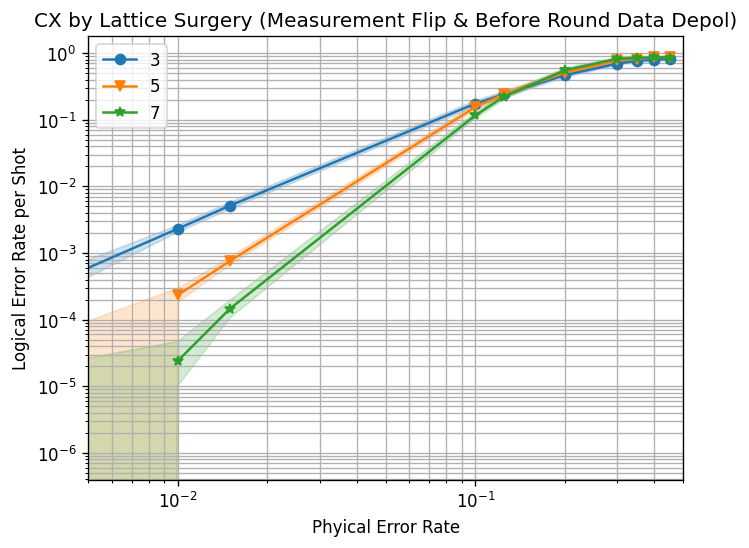

In [18]:
fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance']
)
ax.loglog()
ax.set_xlim(5e-3, 0.5)
ax.set_title("CX by Lattice Surgery (Measurement Flip & Before Round Data Depol)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger